# PlantaIa - análisis exploratorio del dataset

**Curso de Inteligencia Artificial · Tarea 1 · Universidad de Montevideo**

**Objetivo.** Describir las mediciones de luz, temperatura y humedad, y evaluar
su relación con la condición registrada del lirio de paz. El análisis distingue
una asociación estadística de una relación causal: las muestras consecutivas
pertenecen a pocos episodios y no son observaciones independientes.

## 1. Carga y preparación

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
DATOS = RAIZ / "data"
SALIDAS = RAIZ / "outputs"
SALIDAS.mkdir(exist_ok=True)

CLASES = ["saludable", "estresada", "marchita"]
COLORES = {"saludable": "#4c9f70", "estresada": "#e6a23c", "marchita": "#c84b4b"}
sns.set_theme(style="whitegrid", context="notebook")

print("Raíz del proyecto:", RAIZ)
print("pandas", pd.__version__, "· numpy", np.__version__, "· seaborn", sns.__version__)

Matplotlib is building the font cache; this may take a moment.


Raíz del proyecto: /Users/phillip/Desktop/Phillip/IA_Ruperto
pandas 2.3.3 · numpy 2.2.6 · seaborn 0.13.2


In [2]:
archivo = DATOS / "dataset.csv"
df = pd.read_csv(archivo, parse_dates=["ts_local"])
df["etiqueta"] = pd.Categorical(df["etiqueta"], categories=CLASES, ordered=True)

VARIABLES = {
    "luz_mv": "Luz (mV)",
    "temp_aire_c": "Temperatura del aire (°C)",
    "hum_aire_pct": "Humedad del aire (%)",
    "suelo_mv": "Humedad del sustrato (mV; mayor = más seco)",
}
V = list(VARIABLES)

print(f"{archivo.name}: {len(df):,} filas × {df.shape[1]} columnas")
print(f"Período: {df.ts_local.min():%d/%m/%Y %H:%M} a {df.ts_local.max():%d/%m/%Y %H:%M}")
df.head()

dataset.csv: 3,007 filas × 20 columnas
Período: 12/09/2026 19:48 a 17/09/2026 15:59


,ts_local,ts_unix,muestra_id,boot_id,episodio_id,luz_raw,luz_mv,temp_aire_c,hum_aire_pct,suelo_raw,suelo_mv,termistor_raw,termistor_mv,hora_del_dia,es_noche,etiqueta,etiqueta_origen,observacion_manual,wifi_rssi,errores
0,2026-09-12 19:48:02-03:00,1789253282,2,16,1,1923,"1,667.00",21.00,47.00,1099,"1,018.00",4095,"3,124.00",19.80,False,marchita,corregida,False,-91,NaN
1,2026-09-12 19:48:32-03:00,1789253312,3,16,1,1911,"1,662.00",21.00,47.00,1102,"1,015.00",4095,"3,124.00",19.80,False,marchita,corregida,False,-93,NaN
2,2026-09-12 19:49:02-03:00,1789253342,4,16,1,1911,"1,666.00",21.00,47.00,1098,"1,015.00",4095,"3,124.00",19.82,False,marchita,corregida,False,-87,NaN
3,2026-09-12 19:49:32-03:00,1789253372,5,16,1,1920,"1,665.00",21.00,47.00,1105,"1,019.00",4095,"3,124.00",19.82,False,marchita,corregida,False,-87,NaN
4,2026-09-12 19:52:08-03:00,1789253528,6,16,1,1923,"1,674.00",21.00,47.00,1104,"1,019.00",4095,"3,124.00",19.87,False,marchita,corregida,False,-95,NaN


In [3]:
intervalos = df.ts_local.sort_values().diff().dt.total_seconds()
control = pd.Series({
    "filas": len(df),
    "duplicados (boot_id + muestra_id)": df.duplicated(["boot_id", "muestra_id"]).sum(),
    "nulos en las 4 variables analizadas": int(df[V].isna().sum().sum()),
    "mediana entre muestras (s)": intervalos[intervalos <= 900].median(),
    "horas efectivas de registro": intervalos.where(intervalos <= 900, 0).sum() / 3600,
    "episodios de etiqueta": df.episodio_id.nunique(),
    "observaciones manuales": int(df.observacion_manual.sum()),
})
display(control.to_frame("valor"))

display(pd.crosstab(df.etiqueta, df.etiqueta_origen)
        .reindex(CLASES).fillna(0).astype(int))

,valor
filas,"3,007.00"
duplicados (boot_id + muestra_id),0.00
nulos en las 4 variables analizadas,0.00
mediana entre muestras (s),30.00
horas efectivas de registro,25.70
episodios de etiqueta,7.00
observaciones manuales,4.00


etiqueta_origen,corregida,manual,propagada
etiqueta,,,
saludable,0,1,122
estresada,0,2,1126
marchita,1542,1,213


El archivo de análisis no tiene duplicados ni valores faltantes en las cuatro
variables seleccionadas. La temperatura utilizada es la del DHT11; la conversión
del termistor se excluyó porque quedó invertida respecto del sensor de referencia.
La humedad del sustrato se conserva en milivolts porque el porcentaje requiere
calibración: en esta sonda resistiva un valor mayor indica un sustrato más seco.

El registro reúne 3.007 filas, pero la cadencia mediana es de 30 s y sólo hay
7 episodios con 4 observaciones manuales. Por eso las filas consecutivas están
fuertemente correlacionadas y no deben interpretarse como 3.007 observaciones
independientes. La procedencia de cada etiqueta (`manual`, `propagada` o
`corregida`) se conserva para poder evaluar esa limitación.

## 2. Estadística descriptiva

In [4]:
descriptiva = df[V].agg(["mean", "median", "std", "min", "max"]).T
descriptiva.index = [VARIABLES[c] for c in descriptiva.index]
descriptiva.columns = ["media", "mediana", "desvío estándar", "mínimo", "máximo"]
descriptiva.round(2)

,media,mediana,desvío estándar,mínimo,máximo
Luz (mV),"1,377.89",767.00,"1,257.65",142.00,"3,124.00"
Temperatura del aire (°C),15.50,10.90,8.84,8.10,35.60
Humedad del aire (%),49.71,59.00,14.94,18.00,77.00
Humedad del sustrato (mV; mayor = más seco),"2,512.06","2,798.00",466.14,996.00,"3,124.00"


In [5]:
por_condicion = (df.groupby("etiqueta", observed=True)[V]
                   .agg(["mean", "median", "std"]).round(2))
por_condicion

luz_mv                   temp_aire_c             hum_aire_pct  \
              mean   median      std        mean median  std         mean   
etiqueta                                                                    
saludable 3,124.00 3,124.00     0.00       28.07  28.00 1.52        21.98   
estresada 2,050.25 2,080.00 1,179.05       20.18  15.05 9.01        40.83   
marchita    823.68   271.00 1,002.42       11.60   8.90 6.41        57.36   

                       suelo_mv                  
          median   std     mean   median    std  
etiqueta                                         
saludable  22.00  2.21 2,196.46 1,812.00 611.38  
estresada  43.00 14.73 2,235.69 2,064.00 334.61  
marchita   61.00  8.92 2,711.70 2,834.00 422.31

Las distribuciones son muy amplias: la luz combina oscuridad con lecturas en el
techo del ADC, y la temperatura abarca de 8,1 °C a 35,6 °C. En consecuencia, la
media y la mediana pueden diferir bastante y conviene mirar también la forma de
la distribución. Las diferencias entre condiciones son grandes, sobre todo en
temperatura y humedad del sustrato, pero todavía no permiten afirmar causalidad:
cada condición fue registrada en momentos distintos.

## 3. Distribuciones y condición de la planta

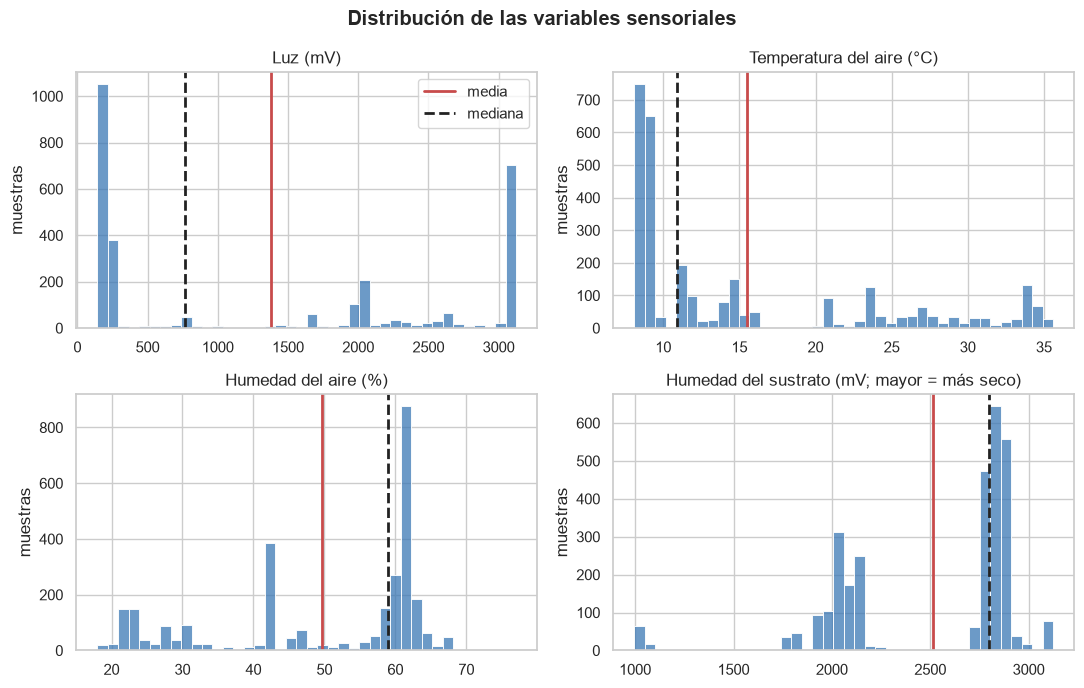

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (col, titulo) in zip(axes.ravel(), VARIABLES.items()):
    sns.histplot(df, x=col, bins=40, color="#3b78b5", ax=ax)
    ax.axvline(df[col].mean(), color="#c84b4b", lw=2, label="media")
    ax.axvline(df[col].median(), color="#222222", lw=2, ls="--", label="mediana")
    ax.set(title=titulo, xlabel="", ylabel="muestras")
axes[0, 0].legend()
fig.suptitle("Distribución de las variables sensoriales", fontweight="bold")
fig.tight_layout()
fig.savefig(SALIDAS / "01_histogramas.png", dpi=150, bbox_inches="tight")
plt.show()

Las cuatro variables son multimodales. La luz acumula observaciones cerca de la
oscuridad y del límite superior del ADC; la temperatura presenta un grupo grande
alrededor de 9 °C y otros entre 20 °C y 35 °C. Esto refleja que el registro
combina tramos de día y noche tomados en jornadas diferentes.

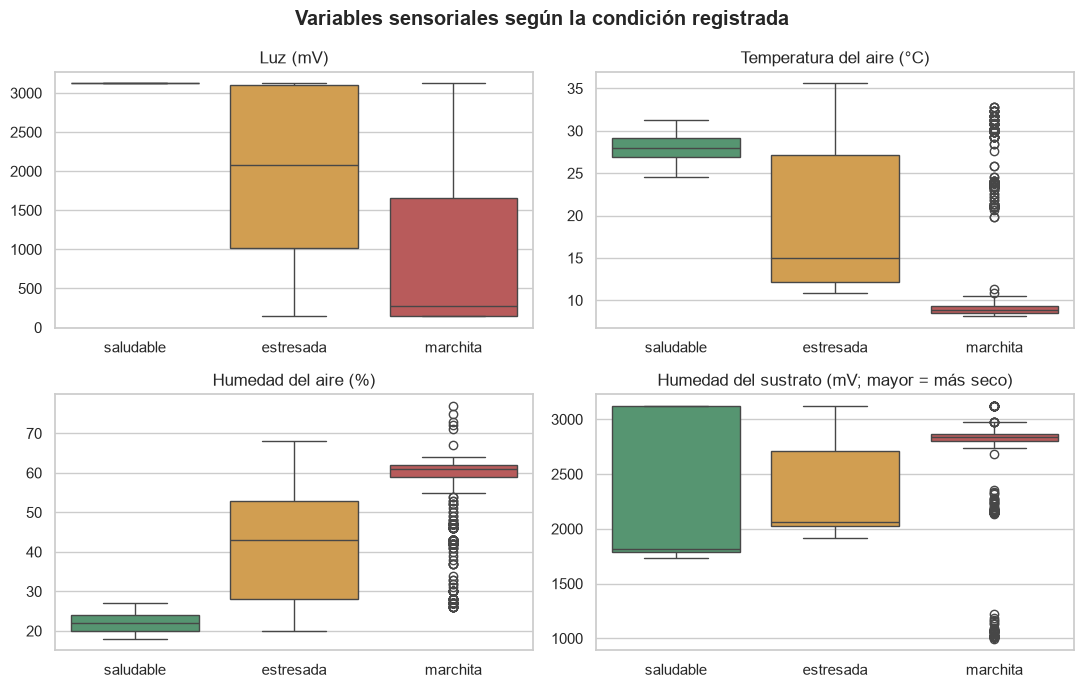

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (col, titulo) in zip(axes.ravel(), VARIABLES.items()):
    sns.boxplot(data=df, x="etiqueta", y=col, hue="etiqueta", order=CLASES,
                palette=COLORES, legend=False, ax=ax)
    ax.set(title=titulo, xlabel="", ylabel="")
fig.suptitle("Variables sensoriales según la condición registrada", fontweight="bold")
fig.tight_layout()
fig.savefig(SALIDAS / "02_boxplots_condicion.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
def epsilon_cuadrado(datos, variable):
    grupos = [datos.loc[datos.etiqueta == c, variable].dropna() for c in CLASES]
    grupos = [g for g in grupos if len(g) > 1]
    H, _ = stats.kruskal(*grupos)
    return (H - len(grupos) + 1) / (len(datos) - len(grupos))

comparacion = []
for nombre, datos in [
    ("dataset completo", df),
    ("sin etiqueta corregida", df[df.etiqueta_origen != "corregida"]),
]:
    for col in V:
        comparacion.append({
            "conjunto": nombre,
            "variable": VARIABLES[col],
            "epsilon²": epsilon_cuadrado(datos, col),
        })

(pd.DataFrame(comparacion)
 .pivot(index="variable", columns="conjunto", values="epsilon²")
 .round(3))

conjunto,dataset completo,sin etiqueta corregida
variable,,
Humedad del aire (%),0.34,0.16
Humedad del sustrato (mV; mayor = más seco),0.44,0.18
Luz (mV),0.26,0.16
Temperatura del aire (°C),0.45,0.10


Como la condición es categórica, su asociación con una variable numérica no se
resume con Pearson. Se utilizó Kruskal-Wallis y se informó el tamaño de efecto
epsilon². En el dataset completo los efectos parecen grandes; sin embargo, al
quitar el episodio reconstruido a posteriori, el efecto de la temperatura cae
de 0,45 a 0,10 y los demás quedan entre 0,16 y 0,18. Los p-valores no se usan
para concluir porque la autocorrelación entre muestras viola la independencia
que requiere el test.

## 4. Correlaciones entre sensores

El heatmap usa el coeficiente de Pearson para las cuatro variables numéricas.
La condición no se codifica como 1, 2 y 3 dentro del heatmap porque esos números
son categorías, no una escala física; su relación se evaluó por grupos en la
sección anterior.

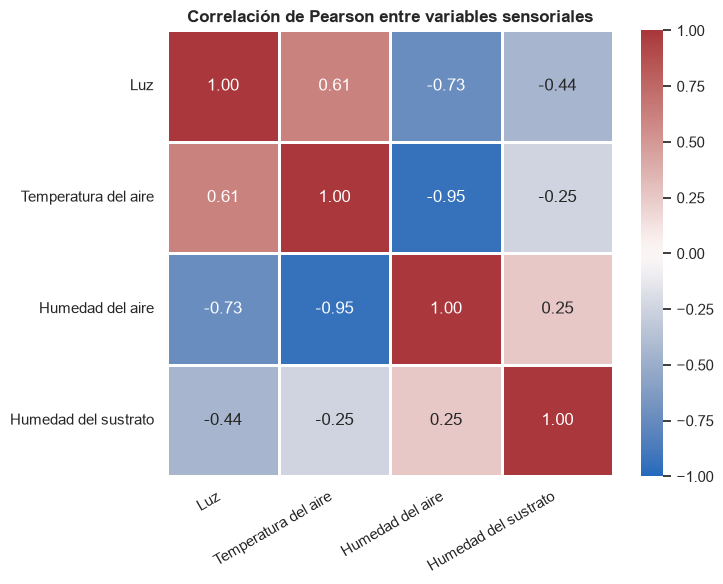

In [9]:
corr = df[V].corr(method="pearson")
rotulos = [VARIABLES[c].split(" (")[0] for c in V]

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, center=0,
            cmap="vlag", square=True, linewidths=1, xticklabels=rotulos,
            yticklabels=rotulos, ax=ax)
ax.set_title("Correlación de Pearson entre variables sensoriales", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()
fig.savefig(SALIDAS / "03_heatmap_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

La relación más fuerte es temperatura-humedad del aire (r = -0,95), esperable
porque la humedad relativa disminuye al aumentar la temperatura si no cambia la
cantidad de vapor de agua. La luz se relaciona positivamente con la temperatura
(r = 0,61) y negativamente con la humedad del aire (r = -0,73), coherente con el
ciclo día/noche. Estas asociaciones describen el ambiente; por sí solas no
demuestran una respuesta de la planta.

## 5. Patrón temporal y principal limitación

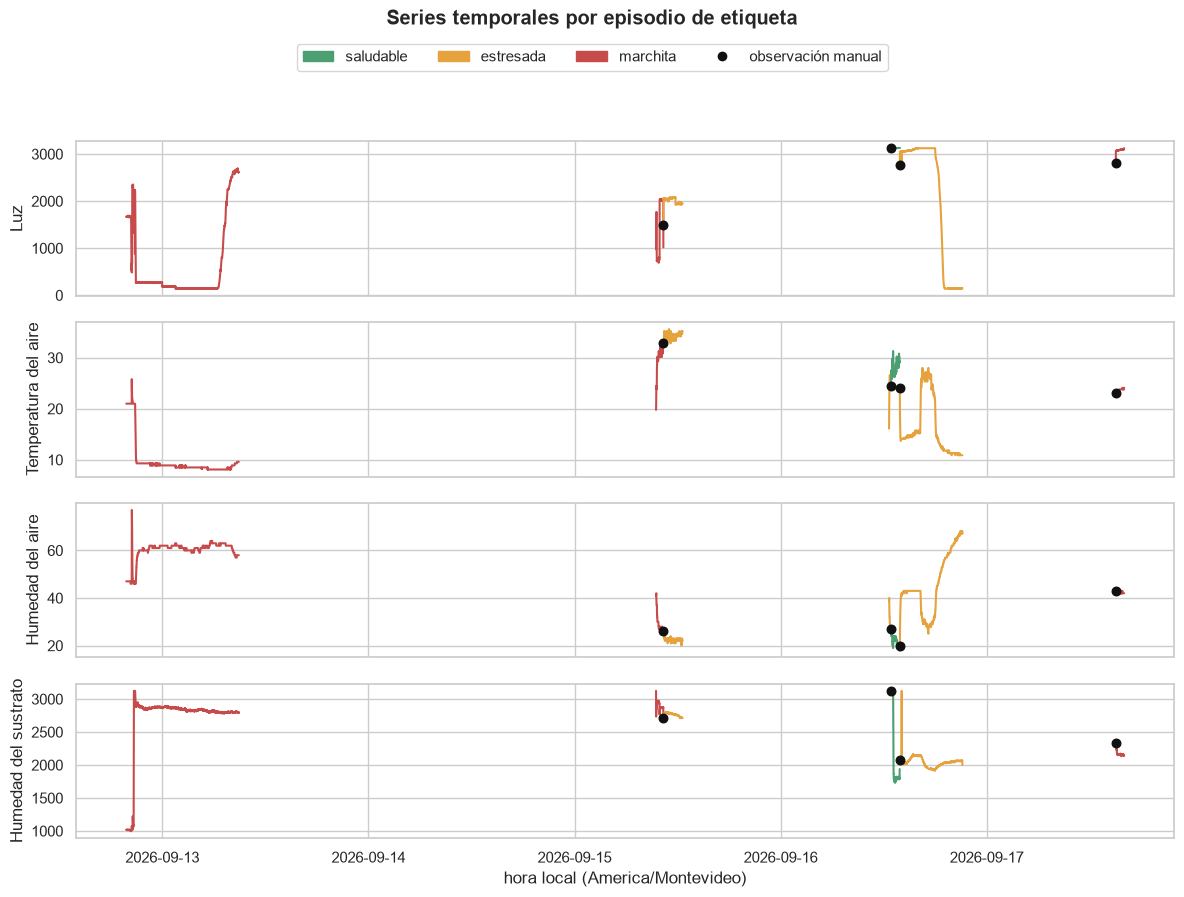

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
for ax, (col, titulo) in zip(axes, VARIABLES.items()):
    for episodio in df.episodio_id.unique():
        tramo = df[df.episodio_id == episodio]
        clase = str(tramo.etiqueta.iloc[0])
        ax.plot(tramo.ts_local, tramo[col], color=COLORES[clase], lw=1.5)
    manual = df[df.observacion_manual]
    ax.scatter(manual.ts_local, manual[col], color="#111111", s=38, zorder=5)
    ax.set_ylabel(titulo.split(" (")[0])

axes[-1].set_xlabel("hora local (America/Montevideo)")
fig.legend(handles=[Patch(color=COLORES[c], label=c) for c in CLASES]
           + [plt.Line2D([], [], marker="o", ls="", color="#111111",
                         label="observación manual")],
           loc="upper center", bbox_to_anchor=(0.5, 0.965), ncol=4)
fig.suptitle("Series temporales por episodio de etiqueta", fontweight="bold", y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.savefig(SALIDAS / "04_series_temporales.png", dpi=150, bbox_inches="tight")
plt.show()

Cada clase ocupa bloques temporales diferentes y casi no se repite en condiciones
ambientales comparables. Por ejemplo, gran parte de `marchita` pertenece a una
noche fría, mientras que `saludable` aparece en un tramo diurno breve. Así, una
variable que cambia con la hora puede parecer asociada con la condición aunque
la planta no sea la causa: etiqueta y tiempo están confundidos.

La serie del sustrato sí muestra una caída brusca el 16/09, compatible con un
riego, seguida por una observación `saludable`. Es un patrón físicamente
plausible, pero se presenta como indicio y no como prueba porque el evento de
riego no fue registrado de forma independiente.

## 6. Conclusiones

1. El dataset entregable contiene 3.007 registros válidos de luz, temperatura,
   humedad del aire y humedad del sustrato, con fecha, hora y condición de la
   planta. No presenta duplicados ni nulos en las variables analizadas.
2. Los sensores reproducen patrones ambientales coherentes: temperatura y
   humedad relativa tienen una correlación de -0,95; la luz se asocia con mayor
   temperatura y menor humedad del aire.
3. Las variables muestran diferencias entre etiquetas, pero no puede afirmarse
   que expliquen la condición de la planta. Las clases fueron registradas en
   bloques horarios distintos y el efecto aparente de la temperatura cae de
   0,45 a 0,10 al excluir la etiqueta reconstruida.
4. El cambio abrupto de humedad del sustrato del 16/09 es el indicio más claro
   de una relación entre manejo, sensor y condición, aunque falta un registro
   independiente del riego para confirmarlo.
5. Para una etapa de modelado hacen falta más episodios y más observaciones
   manuales en días y horarios variados. También conviene registrar cada riego,
   calibrar semanalmente la sonda resistiva y mantener la cadencia normal de
   5 min; aumentar la frecuencia agrega filas, no información independiente.

En síntesis, el sistema permitió construir y analizar el dataset pedido, pero la
evidencia actual alcanza para describir asociaciones y limitaciones, no para
atribuir causalidad ni validar todavía un clasificador generalizable.